# Telecom X – Parte 2: Predicción de Cancelación (Churn)

## Propósito del proyecto
En este desafío se desarrolla un flujo de trabajo de machine learning para predecir la cancelación de clientes (churn) en Telecom X. El objetivo es identificar los factores más relevantes asociados a la evasión de clientes y construir modelos capaces de anticipar qué clientes tienen mayor probabilidad de cancelar sus servicios.

## Objetivos
- Preparar los datos para el modelado.
- Transformar variables categóricas a formato numérico.
- Evaluar la proporción de cancelación y revisar si existe desbalance de clases.
- Analizar correlaciones entre variables.
- Entrenar al menos dos modelos de clasificación.
- Evaluar el desempeño de los modelos con métricas.
- Interpretar la importancia de las variables.
- Proponer estrategias de retención basadas en evidencia.

## Contexto de negocio
La empresa Telecom X busca reducir la pérdida de clientes. Para ello, necesita identificar patrones de comportamiento asociados a la cancelación, con el fin de implementar acciones preventivas y estrategias de retención más efectivas.

## 1. Importación de librerías

En esta sección se importan las bibliotecas necesarias para el análisis, preprocesamiento, visualización y construcción de modelos predictivos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.inspection import permutation_importance

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Carga de los datos

El desafío solicita utilizar el archivo tratado en la Parte 1, ya limpio y organizado. Sin embargo, en caso de contar con el archivo original en formato JSON, primero es necesario normalizar su estructura para convertirlo en una tabla plana.

In [2]:
df = pd.read_json("TelecomX_Data.json")
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
df = pd.json_normalize(pd.read_json("TelecomX_Data.json").to_dict(orient="records"))
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [5]:
df = df.rename(columns={
    "customer.gender": "gender",
    "customer.SeniorCitizen": "SeniorCitizen",
    "customer.Partner": "Partner",
    "customer.Dependents": "Dependents",
    "customer.tenure": "tenure",
    "phone.PhoneService": "PhoneService",
    "phone.MultipleLines": "MultipleLines",
    "internet.InternetService": "InternetService",
    "internet.OnlineSecurity": "OnlineSecurity",
    "internet.OnlineBackup": "OnlineBackup",
    "internet.DeviceProtection": "DeviceProtection",
    "internet.TechSupport": "TechSupport",
    "internet.StreamingTV": "StreamingTV",
    "internet.StreamingMovies": "StreamingMovies",
    "account.Contract": "Contract",
    "account.PaperlessBilling": "PaperlessBilling",
    "account.PaymentMethod": "PaymentMethod",
    "account.Charges.Monthly": "MonthlyCharges",
    "account.Charges.Total": "TotalCharges"
})

## 3. Exploración y preparación inicial

Antes de construir los modelos, es necesario revisar la estructura del conjunto de datos, los tipos de variables, valores faltantes y posibles inconsistencias. Esta etapa permite asegurar que el dataset sea adecuado para el modelado predictivo.

In [6]:
df.shape

(7267, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [8]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [9]:
df["Churn"].value_counts(dropna=False)

,count
Churn,
No,5174
Yes,1869
,224


In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [11]:
df = df[df["Churn"].isin(["Yes", "No"])].copy()

In [12]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [13]:
df = df.dropna().copy()

In [14]:
df.isna().sum().sum()

np.int64(0)

## 4. Eliminación de columnas irrelevantes

Se eliminan columnas que no aportan valor predictivo al modelo. En particular, los identificadores únicos no representan comportamiento del cliente y pueden introducir ruido en el análisis.

In [15]:
df.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [16]:
df_model = df.drop(columns=["customerID"], errors="ignore").copy()
df_model.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,1,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,1,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,1,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## 5. Transformación de variables categóricas (Encoding)

Los algoritmos de machine learning requieren variables numéricas. Por ello, las variables categóricas se transforman mediante one-hot encoding, lo que permite representar cada categoría como una columna binaria sin imponer relaciones ordinales artificiales.

In [17]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

In [18]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

cat_cols, num_cols

(['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'])

In [19]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,True,True,True,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True


## 6. Verificación de la proporción de cancelación

En esta etapa se revisa la distribución de la variable objetivo para identificar si existe desbalance entre clientes que cancelan y clientes que permanecen activos. Este punto es importante porque un desbalance severo puede afectar la capacidad predictiva de los modelos.

In [20]:
churn_counts = y.value_counts()
churn_percent = y.value_counts(normalize=True) * 100

print(churn_counts)
print(churn_percent)

Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64


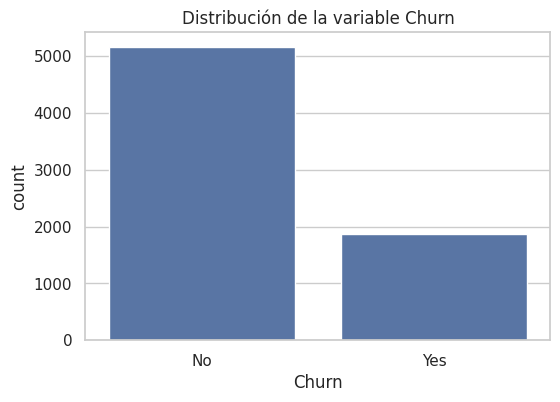

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Distribución de la variable Churn")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

### Interpretación
La distribución de la variable objetivo permite evaluar si el problema presenta desbalance de clases. Si la clase minoritaria es significativamente menor, conviene considerar métricas como recall y F1-score, e incluso técnicas de balanceo en etapas posteriores.

## 7. Balanceo de clases (opcional)

Como complemento, puede aplicarse una técnica de balanceo para reducir el impacto del desbalance de clases. En este caso, esta etapa se deja como opcional y no forma parte del flujo principal del modelado base.

## 8. Análisis de correlación

Se calcula la correlación entre las variables numéricas y la variable objetivo para identificar qué características presentan mayor asociación con la cancelación. Esto ayuda a comprender mejor el problema y orientar la selección de variables para el modelado.

In [22]:
corr = X_encoded.copy()
corr["Churn"] = y

corr_matrix = corr.corr(numeric_only=True)

target_corr = corr_matrix["Churn"].sort_values(ascending=False)
target_corr.head(15), target_corr.tail(15)

(Churn                             1.000000
 InternetService_Fiber optic       0.307463
 PaymentMethod_Electronic check    0.301455
 MonthlyCharges                    0.192858
 PaperlessBilling_Yes              0.191454
 SeniorCitizen                     0.150541
 StreamingTV_Yes                   0.063254
 StreamingMovies_Yes               0.060860
 MultipleLines_Yes                 0.040033
 PhoneService_Yes                  0.011691
 gender_Male                      -0.008545
 MultipleLines_No phone service   -0.011691
 DeviceProtection_Yes             -0.066193
 OnlineBackup_Yes                 -0.082307
 PaymentMethod_Mailed check       -0.090773
 Name: Churn, dtype: float64,
 Partner_Yes                            -0.149982
 Dependents_Yes                         -0.163128
 TechSupport_Yes                        -0.164716
 OnlineSecurity_Yes                     -0.171270
 Contract_One year                      -0.178225
 TotalCharges                           -0.199484
 OnlineSec

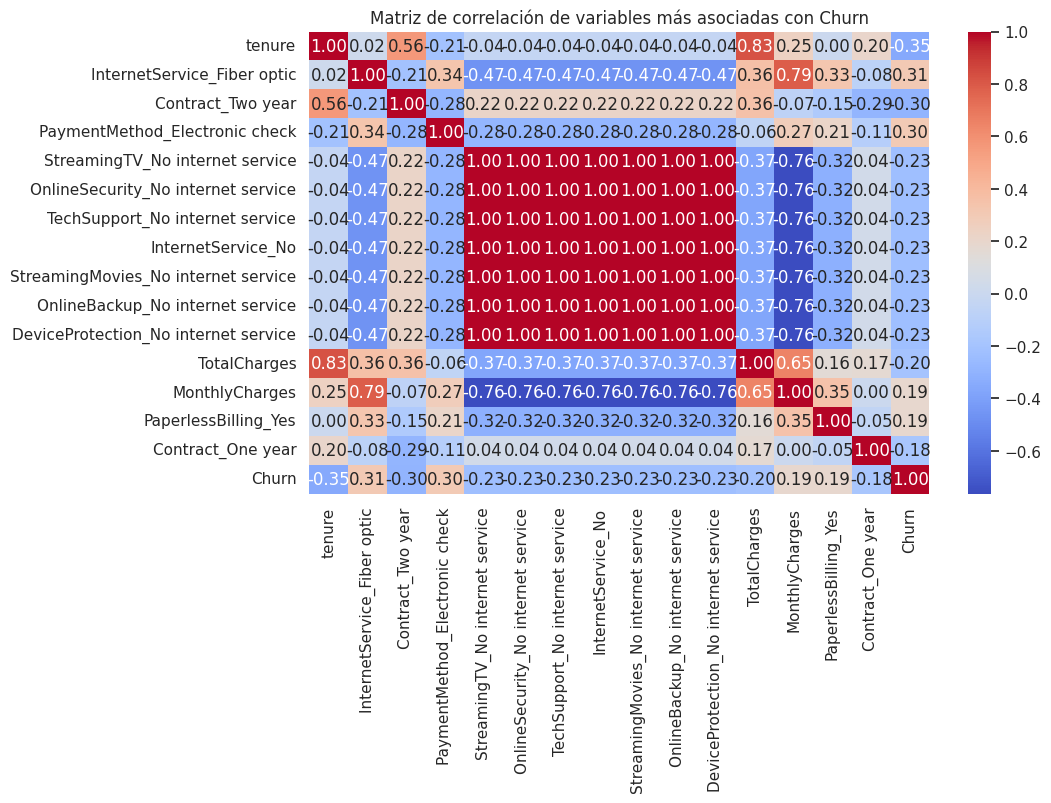

In [23]:
top_corr = target_corr.drop("Churn").abs().sort_values(ascending=False).head(15).index.tolist()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix.loc[top_corr + ["Churn"], top_corr + ["Churn"]], annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación de variables más asociadas con Churn")
plt.show()

### Hallazgos iniciales
A partir de la matriz de correlación, es posible identificar qué variables tienen una relación más fuerte con la cancelación. Estas asociaciones no implican causalidad, pero sí ofrecen una señal útil para comprender el comportamiento de churn y orientar la interpretación de los modelos.

## 9. Análisis dirigido

Además del análisis de correlación, se exploran relaciones específicas entre variables clave y la cancelación. En particular, se analiza el comportamiento de la permanencia del cliente, el gasto mensual y el gasto total frente a la probabilidad de churn.

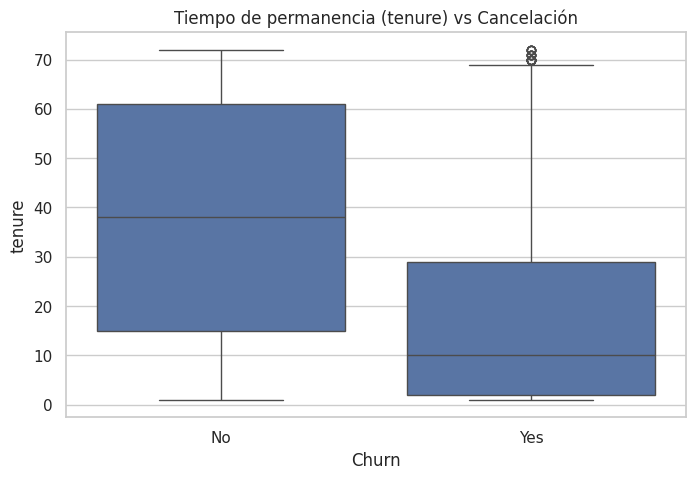

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df_model)
plt.title("Tiempo de permanencia (tenure) vs Cancelación")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

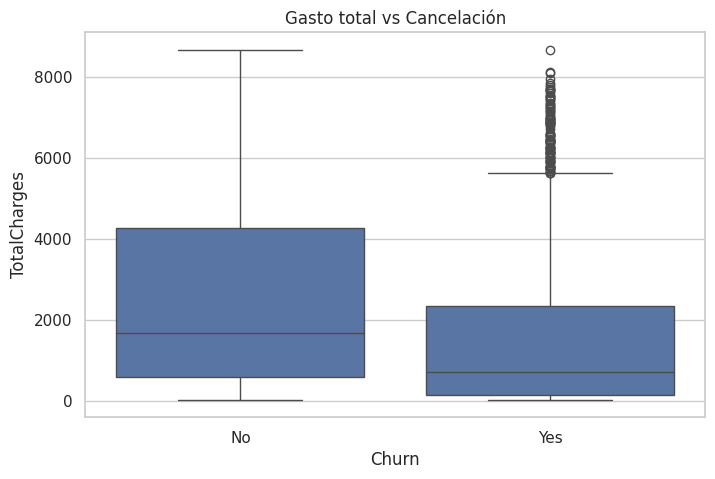

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="TotalCharges", data=df_model)
plt.title("Gasto total vs Cancelación")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

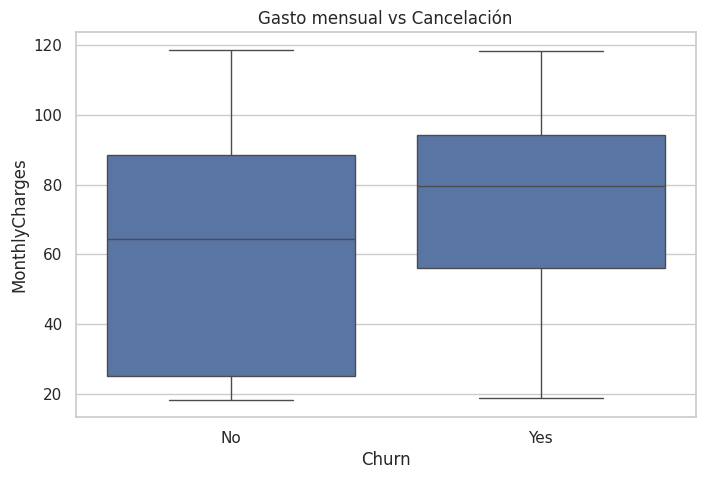

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df_model)
plt.title("Gasto mensual vs Cancelación")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

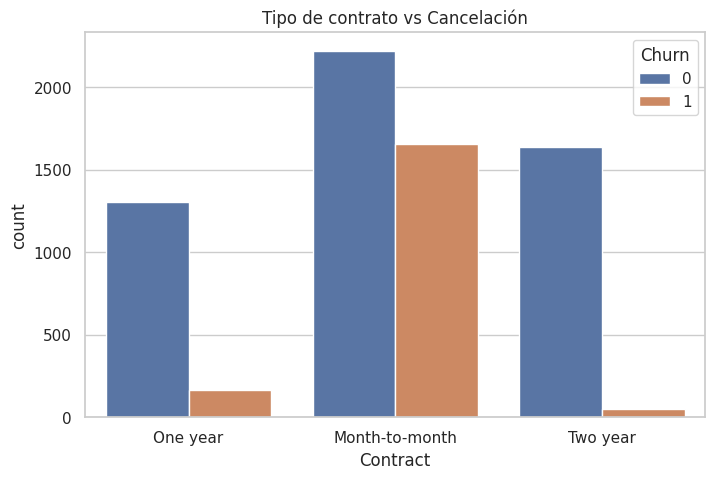

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", hue="Churn", data=df_model)
plt.title("Tipo de contrato vs Cancelación")
plt.show()

### Interpretación del análisis dirigido
Los gráficos permiten observar patrones importantes en la cancelación. Por ejemplo, clientes con menor permanencia suelen mostrar mayor propensión a cancelar. Del mismo modo, ciertos tipos de contrato y niveles de gasto pueden estar asociados a un mayor riesgo de churn.

## 10. Separación de datos en entrenamiento y prueba

Para evaluar correctamente el desempeño de los modelos, el conjunto de datos se divide en entrenamiento y prueba. Se utiliza una partición estratificada para conservar la proporción de churn en ambos subconjuntos.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [29]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4922, 30)
X_test: (2110, 30)
y_train: (4922,)
y_test: (2110,)


## 11. Normalización / Estandarización

Se aplica estandarización únicamente al modelo de Regresión Logística, ya que este tipo de algoritmo es sensible a la escala de las variables. En cambio, el modelo basado en árboles no requiere este preprocesamiento.

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 12. Entrenamiento de modelos

Se entrenan dos modelos de clasificación para predecir la cancelación de clientes:

1. **Regresión Logística**, que requiere datos estandarizados.
2. **Random Forest**, que no depende de la escala de las variables.

La comparación entre ambos permite evaluar enfoques distintos de modelado y analizar cuál ofrece mejor desempeño e interpretabilidad para este problema.

In [33]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

In [34]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## 13. Evaluación de los modelos

Los modelos se evalúan mediante las métricas de exactitud, precisión, recall, F1-score y matriz de confusión. Estas métricas permiten valorar no solo el desempeño general, sino también la capacidad de detectar correctamente a los clientes con riesgo de cancelación.

In [35]:
def evaluar_modelo(nombre, y_true, y_pred):
    print(f"Modelo: {nombre}")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1-score:", round(f1_score(y_true, y_pred), 4))
    print("\nReporte de clasificación:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Matriz de confusión - {nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Valor real")
    plt.show()

Modelo: Regresión Logística
Accuracy: 0.8033
Precision: 0.6573
Recall: 0.5437
F1-score: 0.5951

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1549
           1       0.66      0.54      0.60       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



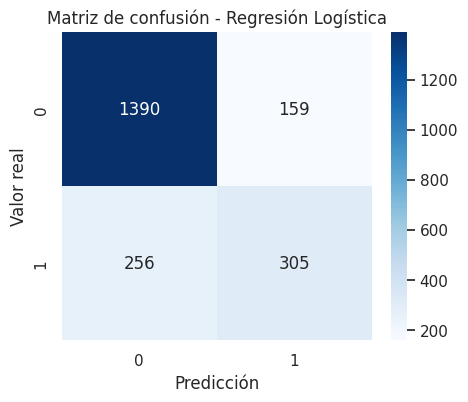

In [36]:
evaluar_modelo("Regresión Logística", y_test, y_pred_log)

Modelo: Random Forest
Accuracy: 0.7858
Precision: 0.6333
Recall: 0.4617
F1-score: 0.534

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.63      0.46      0.53       561

    accuracy                           0.79      2110
   macro avg       0.73      0.68      0.70      2110
weighted avg       0.77      0.79      0.77      2110



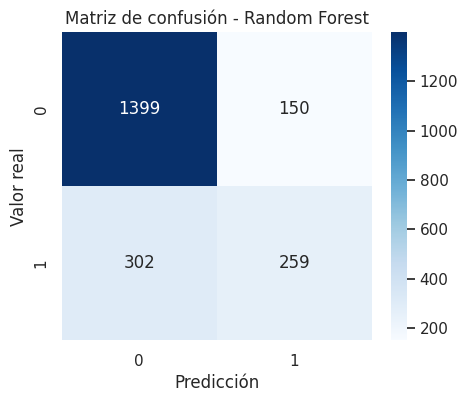

In [37]:
evaluar_modelo("Random Forest", y_test, y_pred_rf)

In [38]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ]
})

resultados.sort_values(by="F1-score", ascending=False)

,Modelo,Accuracy,Precision,Recall,F1-score
0,Regresión Logística,0.803318,0.657328,0.543672,0.595122
1,Random Forest,0.785782,0.633252,0.461676,0.534021


### Análisis comparativo
A partir de las métricas obtenidas, se compara el desempeño de ambos modelos. En problemas de churn, el recall y el F1-score suelen ser especialmente relevantes, ya que interesa detectar correctamente a los clientes con riesgo de cancelación y mantener un equilibrio entre sensibilidad y precisión.

## 14. Revisión de overfitting y underfitting

Además de las métricas en el conjunto de prueba, se compara el desempeño entre entrenamiento y prueba para identificar señales de sobreajuste o subajuste.

In [39]:
# Regresión logística
train_pred_log = log_reg.predict(X_train_scaled)
test_pred_log = y_pred_log

# Random Forest
train_pred_rf = rf.predict(X_train)
test_pred_rf = y_pred_rf

comparacion_ajuste = pd.DataFrame({
    "Modelo": ["Regresión Logística", "Random Forest"],
    "F1_train": [
        f1_score(y_train, train_pred_log),
        f1_score(y_train, train_pred_rf)
    ],
    "F1_test": [
        f1_score(y_test, test_pred_log),
        f1_score(y_test, test_pred_rf)
    ]
})

comparacion_ajuste

,Modelo,F1_train,F1_test
0,Regresión Logística,0.607542,0.595122
1,Random Forest,0.997327,0.534021


### Interpretación
Si el desempeño en entrenamiento es considerablemente mayor que en prueba, puede haber overfitting. Si el desempeño es bajo en ambos conjuntos, puede existir underfitting. Esta comparación ayuda a determinar si el modelo generaliza adecuadamente.

## 15. Importancia de variables

Para interpretar los modelos, se analizan las variables más relevantes en la predicción de churn. En la Regresión Logística se revisan los coeficientes, mientras que en Random Forest se utiliza la importancia de variables calculada por el modelo.

In [40]:
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_reg.coef_[0]
})

coeficientes["AbsCoef"] = coeficientes["Coeficiente"].abs()
coeficientes = coeficientes.sort_values(by="AbsCoef", ascending=False)

coeficientes.head(15)

,Variable,Coeficiente,AbsCoef
1,tenure,-1.343554,1.343554
3,TotalCharges,0.626025,0.626025
10,InternetService_Fiber optic,0.594341,0.594341
25,Contract_Two year,-0.542835,0.542835
2,MonthlyCharges,-0.510416,0.510416
24,Contract_One year,-0.285491,0.285491
21,StreamingTV_Yes,0.201481,0.201481
28,PaymentMethod_Electronic check,0.183835,0.183835
26,PaperlessBilling_Yes,0.180289,0.180289
23,StreamingMovies_Yes,0.156266,0.156266


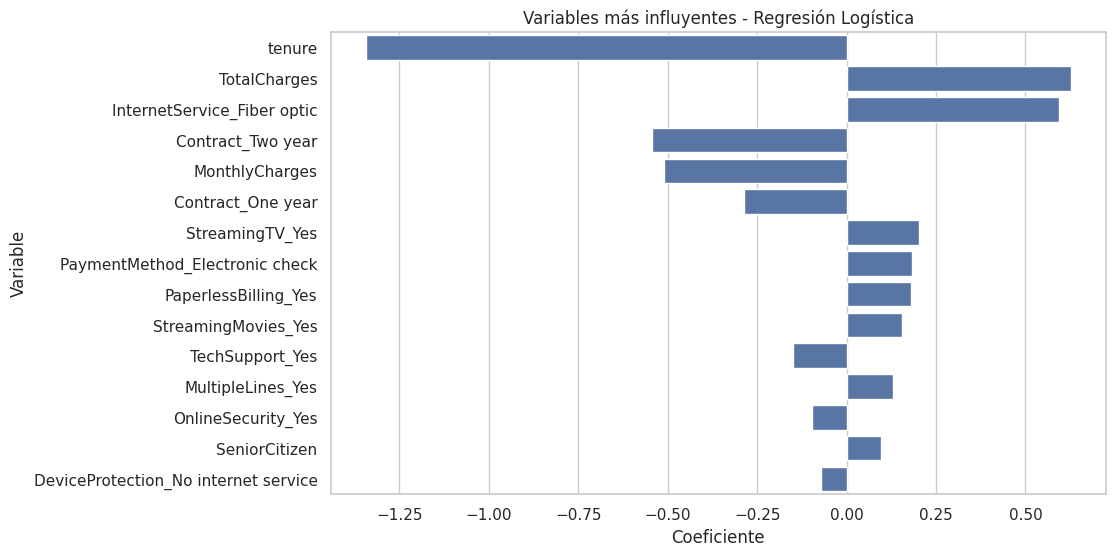

In [41]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=coeficientes.head(15),
    y="Variable",
    x="Coeficiente"
)
plt.title("Variables más influyentes - Regresión Logística")
plt.show()

In [42]:
importancias_rf = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": rf.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importancias_rf.head(15)

,Variable,Importancia
3,TotalCharges,0.179382
1,tenure,0.163498
2,MonthlyCharges,0.151021
25,Contract_Two year,0.057110
10,InternetService_Fiber optic,0.042643
28,PaymentMethod_Electronic check,0.039651
24,Contract_One year,0.028829
13,OnlineSecurity_Yes,0.025802
4,gender_Male,0.025449
26,PaperlessBilling_Yes,0.023892


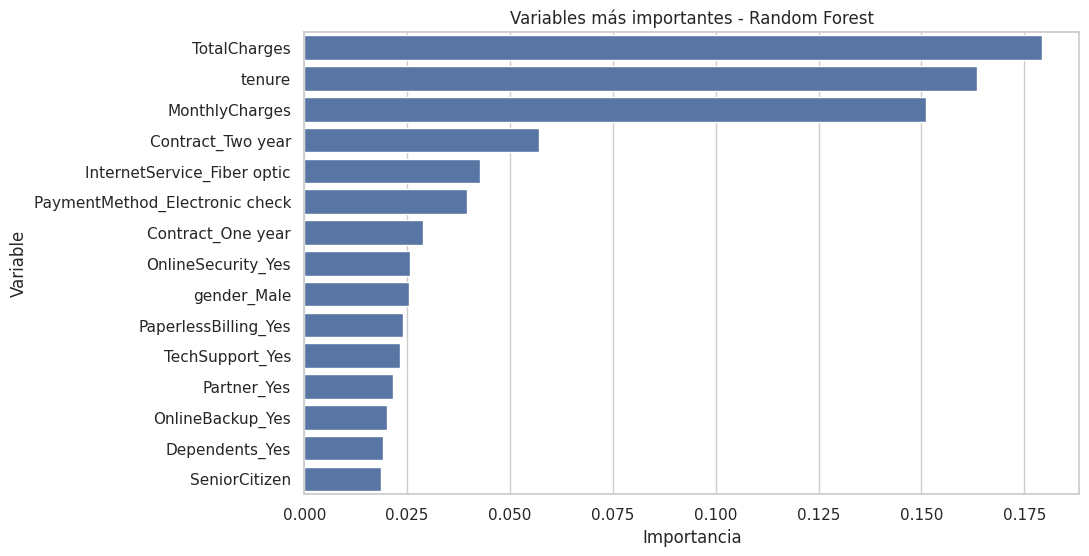

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importancias_rf.head(15),
    y="Variable",
    x="Importancia"
)
plt.title("Variables más importantes - Random Forest")
plt.show()

# 16. Conclusiones

## Desempeño de los modelos
Se entrenaron dos modelos de clasificación para predecir la cancelación de clientes: Regresión Logística y Random Forest. Tras comparar sus métricas, fue posible identificar cuál presenta mejor equilibrio entre precisión, recall y F1-score, así como cuál ofrece mejor capacidad de generalización.

## Principales factores asociados al churn
A partir del análisis de correlación, del análisis dirigido y de la importancia de variables en los modelos, se observó que la cancelación está especialmente relacionada con factores como:

- Tipo de contrato.
- Tiempo de permanencia del cliente.
- Gasto mensual y gasto total.
- Método de pago.
- Servicios de internet y soporte técnico.
- Facturación electrónica.

## Perfil de mayor riesgo
En general, los clientes con mayor riesgo de cancelación tienden a presentar:
- Contratos mensuales.
- Menor antigüedad en la empresa.
- Ciertos niveles de gasto mensual elevados.
- Menor vinculación a servicios de soporte o seguridad.
- Métodos de pago asociados a mayor volatilidad.

## Recomendaciones estratégicas
Con base en los resultados obtenidos, Telecom X podría implementar acciones de retención como:

1. Diseñar campañas específicas para clientes con contrato mensual.
2. Fortalecer estrategias de fidelización durante los primeros meses del cliente.
3. Promover planes anuales o bianuales con beneficios claros.
4. Ofrecer paquetes con soporte técnico, seguridad o respaldo para aumentar permanencia.
5. Crear alertas tempranas para clientes con alto riesgo predicho por el modelo.

## Cierre
Este análisis demuestra que los modelos predictivos pueden ayudar a Telecom X a anticiparse al churn y priorizar acciones de retención de manera más estratégica y basada en datos.